In [ ]:
import os

print("Folders in /kaggle/input:")
print(os.listdir("/kaggle/input"))


In [ ]:
import os
print(os.listdir("/kaggle/input"))



In [ ]:
DATASET_NAME = os.listdir("/kaggle/input")[0]   # or choose the right one
DATASET_PATH = f"/kaggle/input/{DATASET_NAME}"

print("Using:", DATASET_PATH)
print(os.listdir(DATASET_PATH)[:30])


In [ ]:
import glob

VIDEO_DIR = "/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos"

mp4s = glob.glob(VIDEO_DIR + "/**/*.mp4", recursive=True)
avis = glob.glob(VIDEO_DIR + "/**/*.avi", recursive=True)
mkvs = glob.glob(VIDEO_DIR + "/**/*.mkv", recursive=True)

videos = mp4s + avis + mkvs
print("Total videos:", len(videos))
print("Sample:", videos[:5])


In [ ]:
import os, cv2
from tqdm import tqdm

OUT_DIR = "/kaggle/working/frames_1fps"
os.makedirs(OUT_DIR, exist_ok=True)

def extract_1fps(video_path, out_dir):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        cap.release()
        return 0
    step = int(round(fps))  # 1 fps
    frame_idx, saved = 0, 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % step == 0:
            name = os.path.splitext(os.path.basename(video_path))[0]
            cv2.imwrite(os.path.join(out_dir, f"{name}_{frame_idx:07d}.jpg"), frame)
            saved += 1
        frame_idx += 1
    cap.release()
    return saved

# extract from 1-3 videos first (for proof)
for v in videos[:3]:
    s = extract_1fps(v, OUT_DIR)
    print("Frames saved from", os.path.basename(v), ":", s)


In [ ]:
!pip -q install ultralytics
from ultralytics import YOLO
import glob

model = YOLO("yolov8n.pt")

imgs = sorted(glob.glob("/kaggle/working/frames_1fps/*.jpg"))[:200]
results = model(imgs, classes=[0], conf=0.3, save=True)
print("Done. Saved predictions in runs/detect/predict")


In [3]:
import urllib.request
print("Trying to reach pypi...")
urllib.request.urlopen("https://pypi.org", timeout=10)
print("Internet OK ✅")



Trying to reach pypi...
Internet OK ✅


In [4]:
!pip -q install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:0000:01


In [6]:
import os, glob
print("frames_1fps exists?", os.path.exists("/kaggle/working/frames_1fps"))
print("num jpg:", len(glob.glob("/kaggle/working/frames_1fps/*.jpg")))
print("some files:", glob.glob("/kaggle/working/frames_1fps/*.jpg")[:5])


frames_1fps exists? False
num jpg: 0
some files: []


In [7]:
import glob
VIDEO_DIR = "/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos"
videos = glob.glob(VIDEO_DIR + "/**/*.mp4", recursive=True) + glob.glob(VIDEO_DIR + "/**/*.avi", recursive=True)
print("Videos found:", len(videos))
print("Sample:", videos[:3])


Videos found: 170
Sample: ['/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos/Chain_Snatching03.mp4', '/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos/Chain_Snatching46.mp4', '/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos/Chain_Snatching145.mp4']


In [8]:
import os, cv2
from tqdm import tqdm

OUT_DIR = "/kaggle/working/frames_1fps"
os.makedirs(OUT_DIR, exist_ok=True)

def extract_frames(video_path, out_dir, every_n=30, max_frames=1000):
    cap = cv2.VideoCapture(video_path)
    idx, saved = 0, 0
    name = os.path.splitext(os.path.basename(video_path))[0]

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % every_n == 0:
            cv2.imwrite(os.path.join(out_dir, f"{name}_{idx:07d}.jpg"), frame)
            saved += 1
            if saved >= max_frames:
                break
        idx += 1

    cap.release()
    return saved

# extract from first 2 videos (for demo)
for v in videos[:2]:
    s = extract_frames(v, OUT_DIR, every_n=30, max_frames=500)
    print("Extracted", s, "frames from", os.path.basename(v))


Extracted 12 frames from Chain_Snatching03.mp4
Extracted 10 frames from Chain_Snatching46.mp4


In [10]:
import glob
print("Frames now:", len(glob.glob("/kaggle/working/frames_1fps/*.jpg")))


Frames now: 22


In [11]:
import torch, glob

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

imgs = sorted(glob.glob("/kaggle/working/frames_1fps/*.jpg"))[:50]
print("Using images:", len(imgs))

results = model(imgs)
results.save(save_dir="/kaggle/working/yolo_preds")

print("Saved to /kaggle/working/yolo_preds ✅")


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-1-15 Python-3.12.12 torch-2.8.0+cu126 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


Using images: 22


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
Saved 22 images to /kaggle/working/yolo_preds


Saved to /kaggle/working/yolo_preds ✅


In [17]:
import os
print(os.listdir("/kaggle/working/yolo_preds")[:50])


['Chain_Snatching46_0000210.jpg', 'Chain_Snatching03_0000240.jpg', 'Chain_Snatching46_0000120.jpg', 'Chain_Snatching46_0000240.jpg', 'Chain_Snatching03_0000150.jpg', 'Chain_Snatching03_0000120.jpg', 'Chain_Snatching46_0000030.jpg', 'Chain_Snatching03_0000090.jpg', 'Chain_Snatching46_0000000.jpg', 'Chain_Snatching03_0000270.jpg', 'Chain_Snatching46_0000150.jpg', 'Chain_Snatching46_0000180.jpg', 'Chain_Snatching03_0000210.jpg', 'Chain_Snatching03_0000330.jpg', 'Chain_Snatching46_0000270.jpg', 'Chain_Snatching03_0000030.jpg', 'Chain_Snatching03_0000180.jpg', 'Chain_Snatching03_0000060.jpg', 'Chain_Snatching46_0000090.jpg', 'Chain_Snatching03_0000300.jpg', 'Chain_Snatching46_0000060.jpg', 'Chain_Snatching03_0000000.jpg']


In [18]:
import glob
files = glob.glob("/kaggle/working/yolo_preds/**/*.*", recursive=True)
print("Total files:", len(files))
print("Sample files:", files[:15])



Total files: 22
Sample files: ['/kaggle/working/yolo_preds/Chain_Snatching46_0000210.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000240.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000120.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000240.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000150.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000120.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000030.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000090.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000000.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000270.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000150.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000180.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000210.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000330.jpg', '/kaggle/working/yolo_preds/Chain_Snatching46_0000270.jpg']


In [19]:
import matplotlib.pyplot as plt
import cv2
import glob

preds = (
    glob.glob("/kaggle/working/yolo_preds/**/*.jpg", recursive=True) +
    glob.glob("/kaggle/working/yolo_preds/**/*.png", recursive=True) +
    glob.glob("/kaggle/working/yolo_preds/**/*.jpeg", recursive=True)
)

preds = sorted(preds)[:6]
print("Found images:", len(preds))
print("First few:", preds[:3])

plt.figure(figsize=(18, 6))
for i, p in enumerate(preds):
    img_bgr = cv2.imread(p)
    if img_bgr is None:
        print("Could not read:", p)
        continue
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 6, i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()


Found images: 6
First few: ['/kaggle/working/yolo_preds/Chain_Snatching03_0000000.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000030.jpg', '/kaggle/working/yolo_preds/Chain_Snatching03_0000060.jpg']


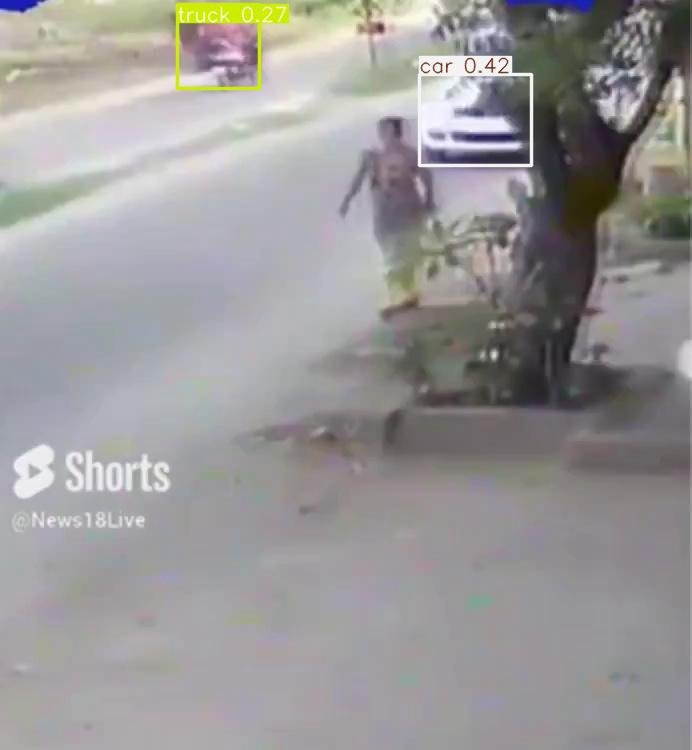

In [21]:
from PIL import Image
Image.open(preds[0])



In [22]:
import os, glob
FRAME_DIR = "/kaggle/working/frames_1fps"
PRED_DIR  = "/kaggle/working/yolo_preds"
OUT_DIR   = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

frames = sorted(glob.glob(FRAME_DIR + "/*.jpg"))
print("Frames:", len(frames))


Frames: 22


In [23]:
import pandas as pd

# Use your existing YOLOv5 model from torch hub:
# model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

results = model(frames)                 # run on all extracted frames
dfs = results.pandas().xyxy             # list of df, one per image

all_rows = []
for i, df in enumerate(dfs):
    if df is None or len(df)==0: 
        continue
    df = df.copy()
    df["frame_idx"] = i
    df["frame_file"] = os.path.basename(frames[i])
    all_rows.append(df)

det_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
det_path = os.path.join(OUT_DIR, "detections.csv")
det_df.to_csv(det_path, index=False)

print("Saved:", det_path)
det_df.head()


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Saved: /kaggle/working/outputs/detections.csv


,xmin,ymin,xmax,ymax,confidence,class,name,frame_idx,frame_file
0,419.335266,74.220360,531.884827,165.031723,0.417014,2,car,0,Chain_Snatching03_0000000.jpg
1,177.266434,4.040855,259.570160,88.541771,0.266816,7,truck,0,Chain_Snatching03_0000000.jpg
2,253.489090,235.842575,290.462372,312.224335,0.803958,0,person,1,Chain_Snatching03_0000030.jpg
3,428.649597,269.410858,604.563232,431.174255,0.679410,2,car,1,Chain_Snatching03_0000030.jpg
4,397.172394,356.986145,479.066528,575.003967,0.532421,0,person,1,Chain_Snatching03_0000030.jpg


In [24]:
import numpy as np

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    if inter <= 0:
        return 0.0
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter)

# filter only people
people_df = det_df[det_df["name"]=="person"].copy()
people_df = people_df.sort_values(["frame_idx"])

next_id = 0
active_tracks = {}  # tid -> last_box
track_rows = []

for frame_idx in sorted(people_df["frame_idx"].unique()):
    df_f = people_df[people_df["frame_idx"]==frame_idx]
    assigned = set()

    for _, row in df_f.iterrows():
        box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]

        # find best match
        best_tid, best_score = None, 0.0
        for tid, last_box in active_tracks.items():
            score = iou(box, last_box)
            if score > best_score:
                best_score = score
                best_tid = tid

        # decide tid
        if best_tid is not None and best_score > 0.3 and best_tid not in assigned:
            tid = best_tid
        else:
            tid = next_id
            next_id += 1

        active_tracks[tid] = box
        assigned.add(tid)

        cx = float((box[0] + box[2]) / 2)
        cy = float((box[1] + box[3]) / 2)
        track_rows.append([frame_idx, tid, cx, cy, float(row["confidence"]), row["frame_file"]])

traj_df = pd.DataFrame(track_rows, columns=["frame", "track_id", "cx", "cy", "conf", "frame_file"])
traj_path = os.path.join(OUT_DIR, "trajectories.csv")
traj_df.to_csv(traj_path, index=False)

print("Saved:", traj_path)
traj_df.head()


Saved: /kaggle/working/outputs/trajectories.csv


,frame,track_id,cx,cy,conf,frame_file
0,1,0,271.975731,274.033455,0.803958,Chain_Snatching03_0000030.jpg
1,1,1,438.119461,465.995056,0.532421,Chain_Snatching03_0000030.jpg
2,1,2,391.550751,257.956352,0.423780,Chain_Snatching03_0000030.jpg
3,2,1,407.980499,423.930634,0.766156,Chain_Snatching03_0000060.jpg
4,3,3,632.710785,357.882996,0.618290,Chain_Snatching03_0000090.jpg


In [25]:
traj_df = traj_df.sort_values(["track_id","frame"])

traj_df["vx"] = traj_df.groupby("track_id")["cx"].diff().fillna(0)
traj_df["vy"] = traj_df.groupby("track_id")["cy"].diff().fillna(0)
traj_df["speed"] = np.sqrt(traj_df["vx"]**2 + traj_df["vy"]**2)

# normalize speed
max_speed = traj_df["speed"].quantile(0.95) + 1e-6
traj_df["speed_norm"] = (traj_df["speed"] / max_speed).clip(0, 1)

# frame anomaly score = max speed norm among tracks
frame_score = traj_df.groupby("frame")["speed_norm"].max().reset_index()
frame_score["anomaly_score"] = frame_score["speed_norm"]
score_path = os.path.join(OUT_DIR, "anomaly_scores.csv")
frame_score.to_csv(score_path, index=False)

print("Saved:", score_path)
frame_score.head()


Saved: /kaggle/working/outputs/anomaly_scores.csv


,frame,speed_norm,anomaly_score
0,1,0.000000,0.000000
1,2,0.454208,0.454208
2,3,0.414484,0.414484
3,4,0.000000,0.000000
4,5,0.000000,0.000000


In [26]:
THRESH = 0.7  # can tune
alerts = frame_score[frame_score["anomaly_score"] > THRESH].copy()

alert_path = os.path.join(OUT_DIR, "alerts.csv")
alerts.to_csv(alert_path, index=False)

print("Total alert frames:", len(alerts))
print("Saved:", alert_path)
alerts.head()


Total alert frames: 6
Saved: /kaggle/working/outputs/alerts.csv


,frame,speed_norm,anomaly_score
6,9,0.832750,0.832750
10,14,0.761702,0.761702
11,15,1.000000,1.000000
12,16,0.862966,0.862966
14,18,1.000000,1.000000


In [27]:
report = f"""
# CCTV Dataset Pipeline Completion Report

## Dataset
- Source: Kaggle chain-snatching-cctv-dataset
- Type: Video-only CCTV clips (no bbox annotations)

## Processing
- Extracted frames: {len(frames)} (sampling ~1fps)

## Detection
- Model: YOLOv5s pretrained (torch hub)
- Output predictions: /kaggle/working/yolo_preds

## Tracking (Baseline)
- Method: IoU-based association
- Output: outputs/trajectories.csv (frame, track_id, cx, cy)

## Behavior / Anomaly (Baseline)
- Metric: speed spike based score
- Output: outputs/anomaly_scores.csv

## Alert Generation
- Threshold: {THRESH}
- Output: outputs/alerts.csv
"""

report_path = os.path.join(OUT_DIR, "report.md")
with open(report_path, "w") as f:
    f.write(report)

print("Saved:", report_path)


Saved: /kaggle/working/outputs/report.md


In [28]:
!zip -r /kaggle/working/cctv_pipeline_outputs.zip /kaggle/working/outputs /kaggle/working/yolo_preds


  adding: kaggle/working/outputs/ (stored 0%)
  adding: kaggle/working/outputs/report.md (deflated 40%)
  adding: kaggle/working/outputs/alerts.csv (deflated 47%)
  adding: kaggle/working/outputs/trajectories.csv (deflated 59%)
  adding: kaggle/working/outputs/anomaly_scores.csv (deflated 60%)
  adding: kaggle/working/outputs/detections.csv (deflated 59%)
  adding: kaggle/working/yolo_preds/ (stored 0%)
  adding: kaggle/working/yolo_preds/Chain_Snatching46_0000210.jpg (deflated 3%)
  adding: kaggle/working/yolo_preds/Chain_Snatching03_0000240.jpg (deflated 3%)
  adding: kaggle/working/yolo_preds/Chain_Snatching46_0000120.jpg (deflated 2%)
  adding: kaggle/working/yolo_preds/Chain_Snatching46_0000240.jpg (deflated 2%)
  adding: kaggle/working/yolo_preds/Chain_Snatching03_0000150.jpg (deflated 2%)
  adding: kaggle/working/yolo_preds/Chain_Snatching03_0000120.jpg (deflated 2%)
  adding: kaggle/working/yolo_preds/Chain_Snatching46_0000030.jpg (deflated 5%)
  adding: kaggle/working/yolo_pre

In [29]:
import os
print(os.path.exists("/kaggle/working/cctv_pipeline_outputs.zip"))
print("Size (MB):", os.path.getsize("/kaggle/working/cctv_pipeline_outputs.zip")/1024/1024)


True
Size (MB): 1.002798080444336
